In [90]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv(r"C:\Users\Junayed\pandas_prac\Aug_21\messy_contractors.csv")

In [92]:
df.head(3)

,ContractorID,ContractorName,ServiceType,City,PhoneNumber,YearsExperience,HourlyRate,JobsCompleted,Rating,Licensed,SignupDate,LastActiveDate,Notes
0,C001,Marcus Reyes,Landscaping,Tulsa,(919) 555-0199,15.0,73.41,305.0,3.8,No,2023-11-20,2024-11-04,NaN
1,C002,Elena Voss,Landscaping,Portland,512-555-0134,18.0,103.82,360.0,4.5,No,2023-08-21,2024-12-21,NaN
2,C003,Rico Callahan,Electrical,Raleigh,(512) 555-0167,3.0,40.06,102.0,4.8,Yes,2023-08-11,2024-11-19,NaN


In [93]:
df.shape

(38, 13)

In [94]:
df.dtypes

ContractorID           str
ContractorName         str
ServiceType            str
City                   str
PhoneNumber            str
YearsExperience    float64
HourlyRate             str
JobsCompleted      float64
Rating             float64
Licensed               str
SignupDate             str
LastActiveDate         str
Notes              float64
dtype: object

## Service Type Normalization & Typo Remediation

**Issue Identified:**  
The `ServiceType` column contains spelling errors (e.g., `"paintng"`), inconsistent uppercase/lowercase formatting (e.g., `"ELECTRICAL"`, `"plumbing"`), and leading/trailing whitespace variations.

**Fix Applied:**  
1. **Typo Correction:** Mapped known typographical errors (`"paintng"` $\rightarrow$ `"Painting"`) using a replacement dictionary.
2. **Case & Whitespace Harmonization:** Stripped extraneous whitespace and standardized all entries into uniform title case using `.astype(str).str.strip().str.title()`.
3. **Frequency Verification:** Evaluated category counts using `.value_counts()` to confirm consistent categorization across all service offerings.

In [95]:
spelling_fix = {
    "paintng" : "Painting"
}

df["ServiceType"] = df["ServiceType"].replace(spelling_fix)
df["ServiceType"] = df["ServiceType"].astype(str).str.strip().str.title()
df["ServiceType"].value_counts()

ServiceType
Plumbing       11
Electrical      9
Landscaping     7
Hvac            7
Painting        4
Name: count, dtype: int64

## Phone Number Standardization & Validation

**Issue Identified:**  
The `PhoneNumber` column contains inconsistent punctuation styles (parentheses, dots, hyphens, unformatted digit strings), incomplete numbers (missing area codes like `555-0177`), and typographical errors (e.g., uppercase letter `'O'` instead of zero `'0'` in `555-01O0`).

**Fix Applied:**  
1. **Punctuation Stripping:** Removed common formatting characters (`(`, `)`, `-`, `.`, and spaces) using regex replacement (`r"[-()\. ]"`).
2. **Structural Validation & Formatting:** Implemented a custom helper function (`form_number`) that validates whether the resulting string contains exactly 10 digits before reformatting into standard `XXX-XXX-XXXX` structure.
3. **Invalid Entry Handling:** Coerced invalid lengths, missing values, or corrupted non-10-digit entries to `np.nan`.
4. **Column Cleanup:** Overwrote `PhoneNumber` with the standardized values and dropped intermediate transformation columns.

In [96]:
df["PhoneDigit"] = df["PhoneNumber"].str.replace(r"[-()\. ]", "", regex=True)

def form_number(val):
    if pd.isna(val):
        return np.nan
    elif len(val) == 10:
        return f"{val[0:3]}-{val[3:6]}-{val[6:10]}"
    else:
        return np.nan

df["PhoneDigit"] = df["PhoneDigit"].apply(form_number)
df["PhoneNumber"] = df["PhoneDigit"]
df.drop(columns = "PhoneDigit", inplace = True)

df["PhoneNumber"]

0     919-555-0199
1     512-555-0134
2     512-555-0167
3     720-555-0181
4     918-555-0129
5     512-555-0198
6     208-555-0134
7     512-555-0159
8     615-555-0153
9     919-555-0112
10    512-555-0126
11    512-555-0122
12    208-555-0170
13    503-555-0130
14    720-555-0161
15    615-555-0131
16    208-555-0188
17             NaN
18    208-555-0190
19    615-555-0173
20    615-555-0193
21    919-555-0103
22    512-555-0147
23    615-555-0185
24    720-555-01O0
25    918-555-0152
26    919-555-0105
27    918-555-0134
28    208-555-0125
29    918-555-0144
30    208-555-0149
31             NaN
32    918-555-0141
33    503-555-0162
34    512-555-0167
35    919-555-0171
36    503-555-0118
37    919-555-0105
Name: PhoneNumber, dtype: str

## Missing Contact Information Annotation

**Objective:**  
Flag records with missing, incomplete, or unparseable telephone data in the audit notes field for subsequent outreach and manual review.

**Fix Applied:**  
1. **Dtype Flexibility:** Explicitly cast `Notes` to `object` data type to accommodate variable-length text strings.
2. **Targeted Flagging:** Applied `.loc[]` indexing combined with `.isna()` filtering on `PhoneNumber` to assign the actionable audit tag (`"Update Phone!"`) directly to non-compliant rows.

In [97]:
df["Notes"] = df["Notes"].astype(object)

df.loc[df["PhoneNumber"].isna(), "Notes"] = "Update Phone!"

# YearsExperience

In [98]:
df["YearsExperience"] = pd.to_numeric(df["YearsExperience"], errors = 'coerce')

## `HourlyRate` Currency Cleaning & Numeric Parsing

**Issue Identified:**  
The `HourlyRate` column contains currency symbols (e.g., `"$85.00"`, `"$102.75"`) and trailing/leading whitespace stored as string objects, preventing arithmetic computation, wage aggregation, and statistical distribution modeling.

**Fix Applied:**  
1. **String Normalization & Whitespace Trimming:** Converted values to string format and stripped extraneous spacing using `.astype(str).str.strip()`.
2. **Currency Symbol Stripping:** Applied regex replacement (`replace(r"[$]", "", regex=True)`) to eliminate dollar signs across all currency records.
3. **Continuous Numeric Conversion:** Coerced the sanitized values to numerical float format using `pd.to_numeric(..., errors='coerce')` while safely mapping non-numeric artifacts to `NaN`.

In [99]:
df["HourlyRate"] = df["HourlyRate"].astype(str).str.strip()
df["HourlyRate"] = df["HourlyRate"].replace(r"[$]", "", regex=True)
df["HourlyRate"] = pd.to_numeric(df["HourlyRate"], errors = 'coerce')
df["HourlyRate"]

0      73.41
1     103.82
2      40.06
3      77.48
4      85.00
5      53.15
6      42.41
7      50.10
8      35.04
9     119.09
10     89.11
11     50.54
12     93.39
13     94.89
14     90.55
15     38.96
16     84.68
17     40.72
18    102.43
19     88.12
20     68.02
21     86.11
22     47.17
23     51.87
24     64.81
25     88.19
26     95.23
27    101.24
28    102.75
29     94.27
30     73.29
31     62.75
32    112.35
33     53.56
34     79.05
35    105.65
36     79.56
37    112.98
Name: HourlyRate, dtype: float64

## Hourly Rate Distribution & Discretization

**Objective:**  
Analyze the density and frequency distribution of service pricing across standardized wage tiers using interval binning and bar chart visualization.

**Methodology & Visualization:**  
1. **Continuous-to-Categorical Binning:** Applied `pd.cut()` across defined intervals ($[\$20, \$120)$ with a step of $\$20$) using `right=False` to create inclusive lower-bound pricing tiers.
2. **Frequency Aggregation:** Calculated segment frequencies via `.value_counts()` and ordered them logically by interval ranges using `.sort_index()`.
3. **Bar Chart Plotting:** Rendered a customized bar chart using `matplotlib.pyplot` to visualize tier counts, complete with custom styling, distinct edge borders, and background y-axis gridlines for scannability.

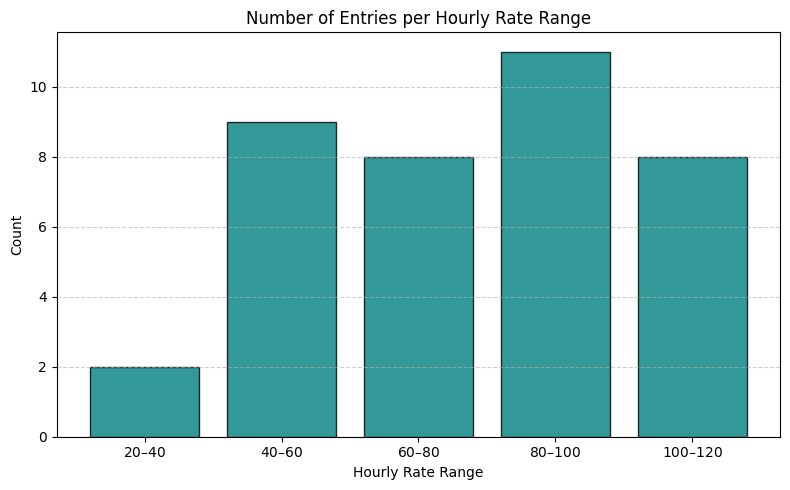

In [100]:
bins = [20, 40, 60, 80, 100, 120]
labels = ["$20–$40", "$40–$60", "$60–$80", "$80–$100", "$100–$120"]
rate_ranges = pd.cut(
    df["HourlyRate"], bins=bins, labels=labels, right=False
).value_counts()
rate_ranges = rate_ranges.sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    rate_ranges.index,
    rate_ranges.values,
    color="teal",
    alpha=0.8,
    edgecolor="black",
)

plt.title("Number of Entries per Hourly Rate Range")
plt.xlabel("Hourly Rate Range")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()